In [4]:
!pip install "protobuf<4" "click<8.1"

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, 
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

In [10]:
MAX_WORDS = 20000
MAX_LEN = 50
EMBEDDING_DIM = 100
GLOVE_FILE = '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt' 
TRAIN_CSV = '/kaggle/input/for-task-sparktech/train.csv'

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"GPU Strategy Active: {strategy.num_replicas_in_sync} Devices")
except:
    strategy = tf.distribute.get_strategy() 
    print("Running on CPU/Single Device")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPU Strategy Active: 2 Devices


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


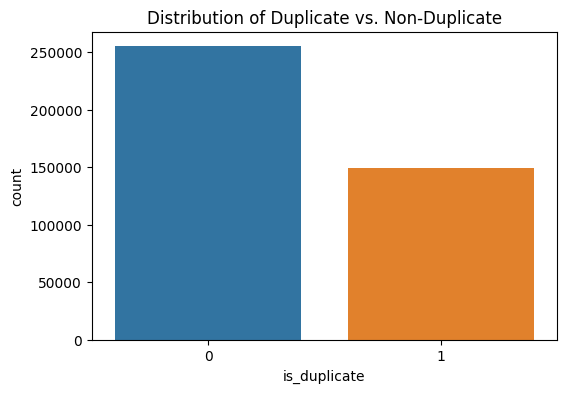

In [11]:
# Data loading, Preprocessing & EDA
df = pd.read_csv(TRAIN_CSV)
df.dropna(subset=['question1', 'question2'], inplace=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) 
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['q1_clean'] = df['question1'].apply(clean_text)
df['q2_clean'] = df['question2'].apply(clean_text)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_duplicate', data=df)
plt.title('Distribution of Duplicate vs. Non-Duplicate')
plt.show()

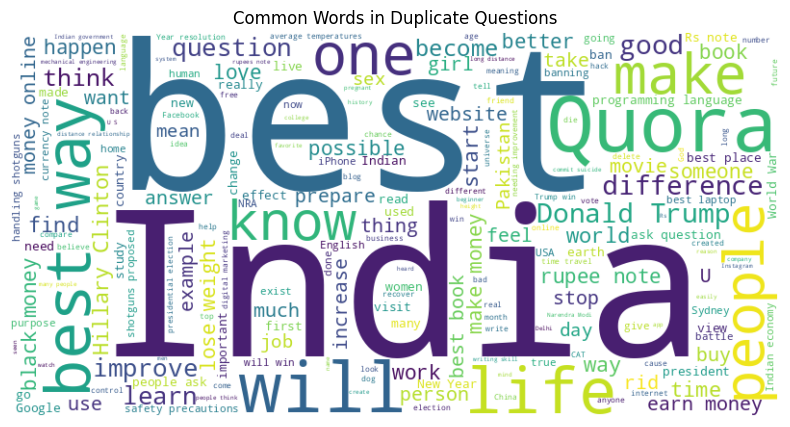

In [12]:
# Word Clouds
text_duplicates = " ".join(df[df['is_duplicate'] == 1]['question1'].astype(str))
wc = WordCloud(width=800, height=400, background_color='white').generate(text_duplicates)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Duplicate Questions')
plt.savefig('eda_wordcloud.png')

In [13]:
# Tokenization & Embedding
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(list(df['q1_clean']) + list(df['q2_clean']))
word_index = tokenizer.word_index

q1_seq = tokenizer.texts_to_sequences(df['q1_clean'])
q2_seq = tokenizer.texts_to_sequences(df['q2_clean'])

q1_data = pad_sequences(q1_seq, maxlen=MAX_LEN)
q2_data = pad_sequences(q2_seq, maxlen=MAX_LEN)
labels = df['is_duplicate'].values

embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
try:
    with open(GLOVE_FILE, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in word_index and word_index[word] < MAX_WORDS:
                embedding_matrix[word_index[word]] = np.asarray(values[1:], dtype='float32')
    print("GloVe loaded successfully.")
except FileNotFoundError:
    print("GloVe file not found.")

def manhattan_distance(vects):
    x, y = vects
    return K.sum(K.abs(x - y), axis=1, keepdims=True)

GloVe loaded successfully.


In [14]:
# Hyperparameter and optimization

def create_lstm_model(learning_rate=0.001, dropout_rate=0.2, lstm_units=64):
    # Model structure
    input_q1 = Input(shape=(MAX_LEN,))
    input_q2 = Input(shape=(MAX_LEN,))

    embedding_layer = Embedding(MAX_WORDS, EMBEDDING_DIM, weights=[embedding_matrix], trainable=False)
    
    shared_lstm = LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.0) 
    
    encoded_q1 = shared_lstm(embedding_layer(input_q1))
    encoded_q2 = shared_lstm(embedding_layer(input_q2))

    distance = tf.keras.layers.Lambda(manhattan_distance)([encoded_q1, encoded_q2])
    output = Dense(1, activation='sigmoid')(distance)

    model = Model(inputs=[input_q1, input_q2], outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

# Prepare Subset for Search 
subset_size = 20000
X1_sub = q1_data[:subset_size]
X2_sub = q2_data[:subset_size]
y_sub = labels[:subset_size]

param_grid = [{'batch_size': 128, 'learning_rate': 0.001, 'units': 64},
    {'batch_size': 256, 'learning_rate': 0.001, 'units': 64},
    {'batch_size': 128, 'learning_rate': 0.0001, 'units': 64}]

best_score = 0.0
best_params = {}

for params in param_grid:
    print(f"Param Test: {params}")
    
    with strategy.scope():
        model = create_lstm_model(
            learning_rate=params['learning_rate'], 
            lstm_units=params['units'])
    
    history = model.fit(
        [X1_sub, X2_sub], y_sub,
        batch_size=params['batch_size'],
        epochs=3,
        validation_split=0.2,
        verbose=0
    )
    
    val_acc = history.history['val_accuracy'][-1]
    print(f"Result: Val Accuracy = {val_acc:.4f}")
    
    if val_acc > best_score:
        best_score = val_acc
        best_params = params

print(f"\nBest param: {best_params}")
print(f"Best Validation Accuracy: {best_score:.4f}")

# Use these best params for the final run
FINAL_BATCH_SIZE = best_params.get('batch_size', 128)
FINAL_LR = best_params.get('learning_rate', 0.0001)

Param Test: {'batch_size': 128, 'learning_rate': 0.001, 'units': 64}
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 5 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_

I0000 00:00:1763664299.436993     124 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763664300.215449     125 cuda_dnn.cc:529] Loaded cuDNN version 90300


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, imple

In [15]:
# Final training on full data

X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(
    q1_data, q2_data, labels, test_size=0.2, random_state=42)

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

with strategy.scope():
    input_q1 = Input(shape=(MAX_LEN,))
    input_q2 = Input(shape=(MAX_LEN,))

    embedding_layer = Embedding(MAX_WORDS, EMBEDDING_DIM, weights=[embedding_matrix], trainable=False)
    shared_lstm = LSTM(64, dropout=0.2, recurrent_dropout=0.0) 
    
    encoded_q1 = shared_lstm(embedding_layer(input_q1))
    encoded_q2 = shared_lstm(embedding_layer(input_q2))

    distance = tf.keras.layers.Lambda(manhattan_distance)([encoded_q1, encoded_q2])
    output = Dense(1, activation='sigmoid')(distance)

    lstm_model = Model(inputs=[input_q1, input_q2], outputs=output)
    lstm_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=FINAL_LR), metrics=['accuracy'])

lstm_history = lstm_model.fit(
    [X1_train, X2_train], y_train,
    validation_data=([X1_test, X2_test], y_test),
    batch_size=FINAL_BATCH_SIZE,  
    epochs=30,       
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 5 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
2527/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: nan - loss: nanINFO:tensorflow:Collective all_reduce tensors: 1 all_reduces, num_devices = 2, group_size = 2, implementation = Commun

In [18]:
## SVM Baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
tfidf = TfidfVectorizer(max_features=25000) 
all_text = list(df['q1_clean']) + list(df['q2_clean'])
tfidf.fit(all_text)

q1_tfidf = tfidf.transform(df['q1_clean'])
q2_tfidf = tfidf.transform(df['q2_clean'])

X_svm = abs(q1_tfidf - q2_tfidf)
y_svm = labels

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42
)

svm_model = LinearSVC(dual=False, C=1.0) 
clf = CalibratedClassifierCV(svm_model) 
clf.fit(X_train_svm, y_train_svm)

svm_pred = clf.predict(X_test_svm)
svm_pred_probs = clf.predict_proba(X_test_svm)[:, 1]

In [19]:
# Evaluation and report

# Auto-find best threshold for LSTM
lstm_pred_probs = lstm_model.predict([X1_test, X2_test], batch_size=FINAL_BATCH_SIZE, verbose=0)
best_threshold = 0.0
best_f1 = 0.0

for thresh in np.arange(0.20, 0.60, 0.01):
    y_guess = (lstm_pred_probs > thresh).astype(int)
    score = f1_score(y_test, y_guess)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

print(f"Optimized Threshold: {best_threshold:.2f}")
lstm_pred = (lstm_pred_probs > best_threshold).astype(int)

Optimized Threshold: 0.37


In [24]:
# Calculate Metrics
try:
    svm_a = accuracy_score(y_test_svm, svm_pred)
    svm_p = precision_score(y_test_svm, svm_pred)
    svm_r = recall_score(y_test_svm, svm_pred)
    svm_f = f1_score(y_test_svm, svm_pred)
    svm_auc = roc_auc_score(y_test_svm, svm_pred_probs)
except:
    svm_a = svm_p = svm_r = svm_f = svm_auc = 0.0

metrics_data = {
    'Model': ['Siamese LSTM', 'SVM Baseline'],
    'Accuracy': [accuracy_score(y_test, lstm_pred), svm_a],
    'Precision': [precision_score(y_test, lstm_pred), svm_p],
    'Recall': [recall_score(y_test, lstm_pred), svm_r],
    'F1-Score': [f1_score(y_test, lstm_pred), svm_f],
    'AUC-ROC': [roc_auc_score(y_test, lstm_pred_probs), svm_auc]}

results_df = pd.DataFrame(metrics_data).round(4)
results_df.to_csv('model_performance_metrics.csv', index=False)

print("\nFINAL RESULTS TABLE")
print(results_df.to_markdown(index=False))


FINAL RESULTS TABLE
| Model        |   Accuracy |   Precision |   Recall |   F1-Score |   AUC-ROC |
|:-------------|-----------:|------------:|---------:|-----------:|----------:|
| Siamese LSTM |     0.7256 |      0.5915 |   0.8121 |     0.6844 |    0.8178 |
| SVM Baseline |     0.7788 |      0.6945 |   0.7077 |     0.701  |    0.8549 |


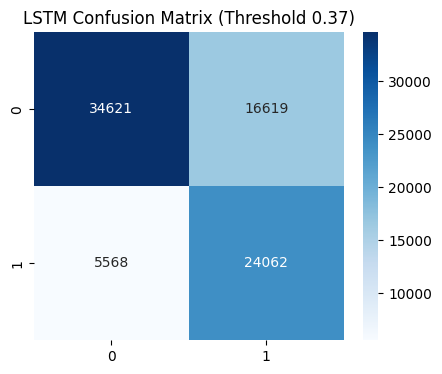

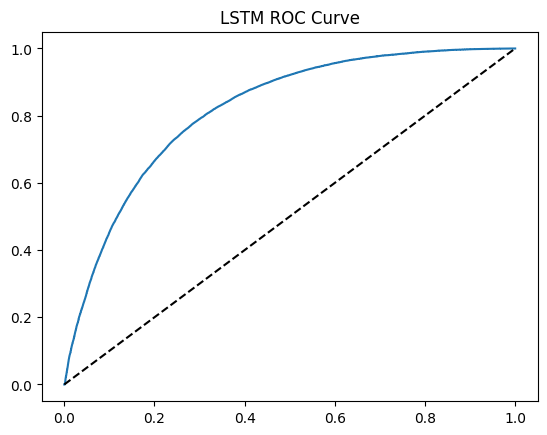

In [25]:
# Final Plots
cm_lstm = confusion_matrix(y_test, lstm_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues')
plt.title(f'LSTM Confusion Matrix (Threshold {best_threshold:.2f})')
plt.savefig('lstm_confusion_matrix.png')
plt.show()

fpr, tpr, _ = roc_curve(y_test, lstm_pred_probs)
plt.figure()
plt.plot(fpr, tpr, label=f'LSTM AUC = {results_df.loc[0, "AUC-ROC"]}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('LSTM ROC Curve')
plt.savefig('lstm_roc_curve.png')
plt.show()

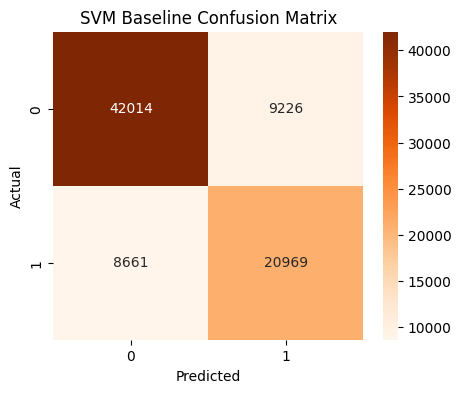

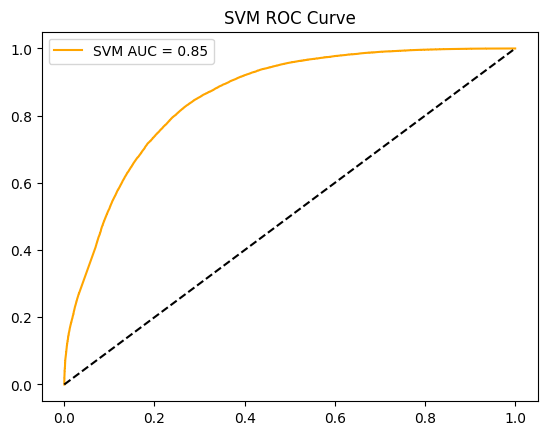

In [26]:
# SVM confusion matrix
cm_svm = confusion_matrix(y_test_svm, svm_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title('SVM Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('svm_confusion_matrix.png')

# SVM Plot
fpr_s, tpr_s, _ = roc_curve(y_test_svm, svm_pred_probs)
svm_auc = auc(fpr_s, tpr_s)
plt.figure()
plt.plot(fpr_s, tpr_s, color='orange', label=f'SVM AUC = {svm_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('SVM ROC Curve')
plt.legend()
plt.savefig('svm_roc_curve.png')

In [29]:
# Comparision

lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_auc = roc_auc_score(y_test, lstm_pred_probs)

try:
    svm_acc = accuracy_score(y_test_svm, svm_pred)
    svm_auc = roc_auc_score(y_test_svm, svm_pred_probs)
except NameError:
    svm_acc = 0.0
    svm_auc = 0.0

print(f"Deep Learning (Siamese LSTM) Accuracy: {lstm_acc:.4f} | AUC: {lstm_auc:.4f}")
print(f"Baseline (SVM + TF-IDF)      Accuracy: {svm_acc:.4f} | AUC: {svm_auc:.4f}")

if lstm_acc > svm_acc:
    print("LSTM outperformed the baseline.")
else:
    print("SVM baseline outperformed the LSTM")

Deep Learning (Siamese LSTM) Accuracy: 0.7256 | AUC: 0.8178
Baseline (SVM + TF-IDF)      Accuracy: 0.7788 | AUC: 0.8549
SVM baseline outperformed the LSTM
